In [1]:
import numpy as np
import cv2 as cv

# 

In [2]:
image = cv.imread('./lenna.png')


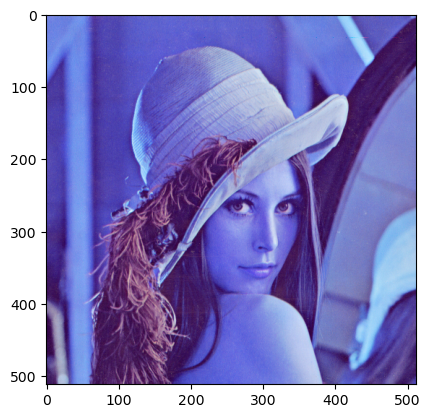

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

#%matplotlib inline позволяет выводить графики matplotlib в Jupyter
plt.imshow(image[:,:,:])

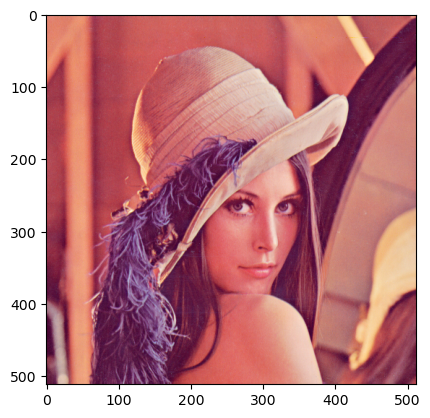

In [4]:
rgb_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(rgb_image)

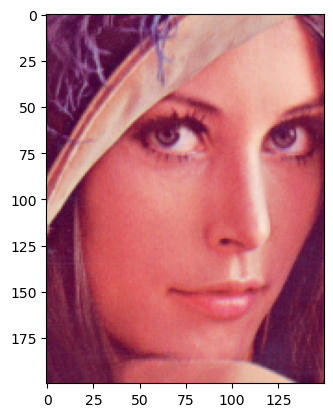

In [5]:
ROI = (200, 200, 150, 200)  #(x0, y0, height, width)
cropped_image = rgb_image[ROI[1]:ROI[1] + ROI[3], ROI[0]:ROI[0] + ROI[2]]
plt.imshow(cropped_image)

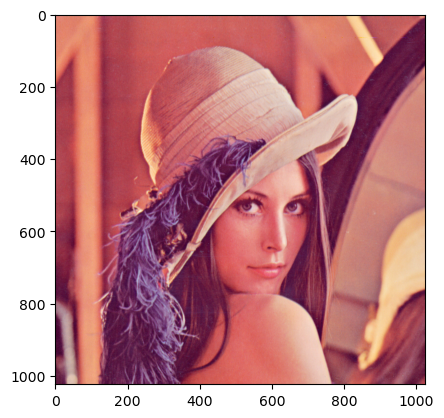

In [6]:
scale_percent = 200
width = int(rgb_image.shape[1] * scale_percent / 100)
height = int(rgb_image.shape[0] * scale_percent / 100)
dim = (width, height)
resized_image = cv.resize(rgb_image, dim, interpolation=cv.INTER_AREA)
plt.imshow(resized_image)

[[ 1.95365564e-01  4.60252427e-01  8.81617943e+01]
 [-4.60252427e-01  1.95365564e-01  3.23811037e+02]]


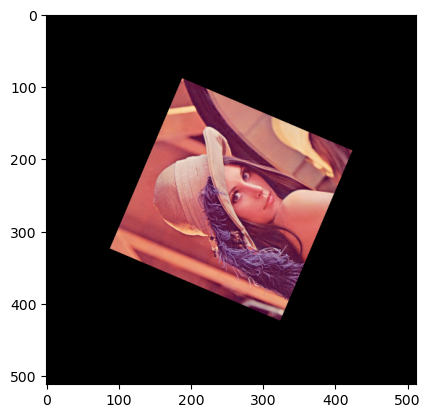

In [7]:
(h, w, d) = rgb_image.shape
angle = 67
scale = 0.5
center = (w // 2, h // 2)
M = cv.getRotationMatrix2D(center, angle, scale)

print(M)
rotated = cv.warpAffine(rgb_image, M, (w, h))
plt.imshow(rotated)

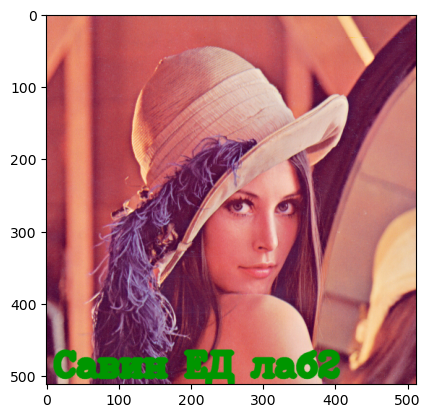

In [8]:
copy_image = rgb_image.copy()
font = cv.FONT_HERSHEY_COMPLEX
#  cv2.putText(image, text, bottomLeft, fontType, fontScale, rgb, thinkness, lineType)
cv.putText(copy_image, 'Савин ЕД лаб2', (10, 500), font, 1.5, (0, 150, 0), 7, cv.LINE_AA)

plt.imshow(copy_image)

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

In [10]:
plt.rcParams["figure.figsize"] = [6, 4]

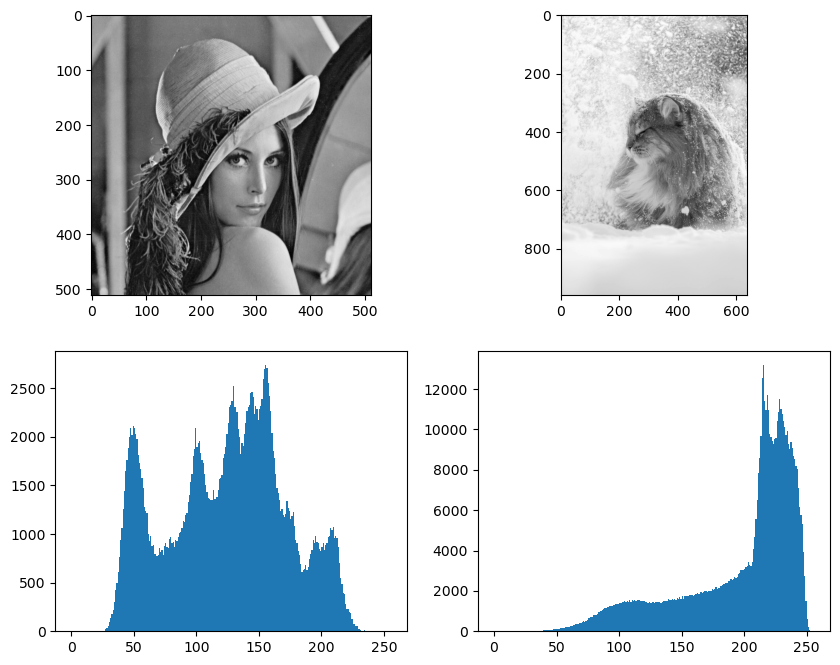

In [11]:
image1 = cv.imread('./lenna.png')
image2 = cv.imread('./winter_cat.png')
rgb_image1 = cv.cvtColor(image1, cv.COLOR_BGR2RGB)
rgb_image2 = cv.cvtColor(image2, cv.COLOR_BGR2RGB)
gray_image1 = cv.cvtColor(image1, cv.COLOR_BGR2GRAY)
gray_image2 = cv.cvtColor(image2, cv.COLOR_BGR2GRAY)

channels = [0]
histSize = [256]
range = [0, 256]

hist1 = cv.calcHist([gray_image1], channels, None, histSize, range)
hist2 = cv.calcHist([gray_image2], channels, None, histSize, range)

gs = plt.GridSpec(2, 2)
plt.figure(figsize=(10, 8))
plt.subplot(gs[0])
plt.imshow(gray_image1, cmap='gray')
plt.subplot(gs[1])
plt.imshow(gray_image2, cmap='gray')
plt.subplot(gs[2])
plt.hist(gray_image1.reshape(-1), 256, range)
plt.subplot(gs[3])
plt.hist(gray_image2.reshape(-1), 256, range)
plt.show()

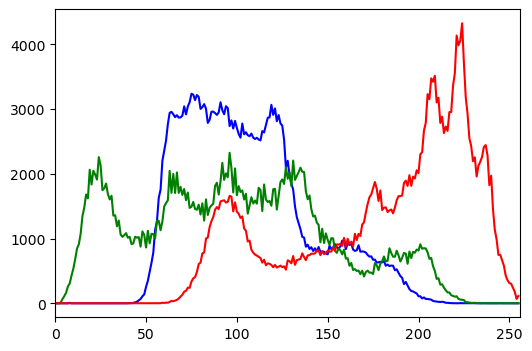

In [12]:
histSize = [256]
range = [0, 256]


def plot_rgb_hist(image, histSize, range):
    histSize = [256]
    range = [0, 256]
    for i, col in enumerate(['b', 'g', 'r']):
        hist = cv.calcHist([image], [i], None, histSize, range)
        plt.plot(hist, color=col)
        plt.xlim(range)


plot_rgb_hist(image1, histSize, range)
plt.show()

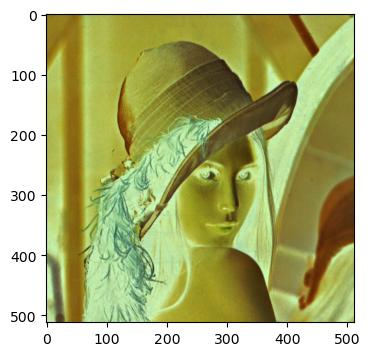

In [13]:
lut = lambda i: 255 - i
invert_image = lut(image1)
plt.imshow(invert_image)

In [14]:
image1 = cv.imread('./lenna.png')
image2 = cv.imread('./winter_cat.png')
gamma = 1.5


def gamma_correction_rgb(image, gamma):
    
    image_normalized = image / 255.0
    
    result = np.power(image_normalized, gamma)
    
    return (result * 255).astype(np.uint8)

In [15]:
result_image = gamma_correction_rgb(rgb_image, gamma)

In [16]:
gs = plt.GridSpec(1, 2)

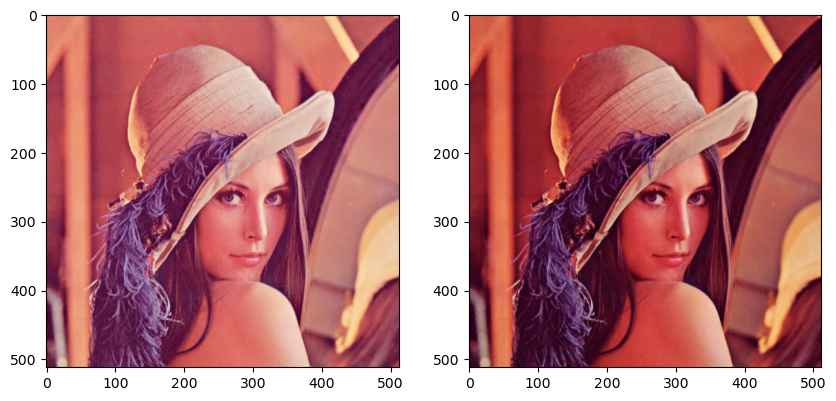

In [17]:
plt.figure(figsize=(10, 8))
plt.subplot(gs[0])
plt.imshow(rgb_image)
plt.subplot(gs[1])
plt.imshow(result_image)

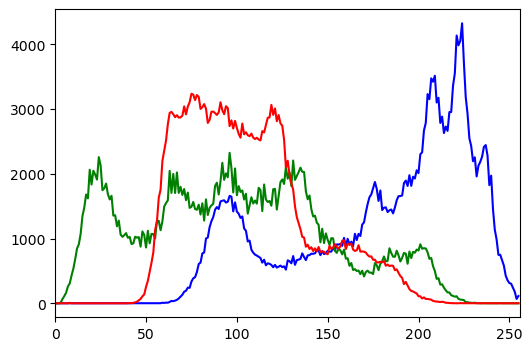

In [18]:
plot_rgb_hist(rgb_image, histSize, range)
plt.show()

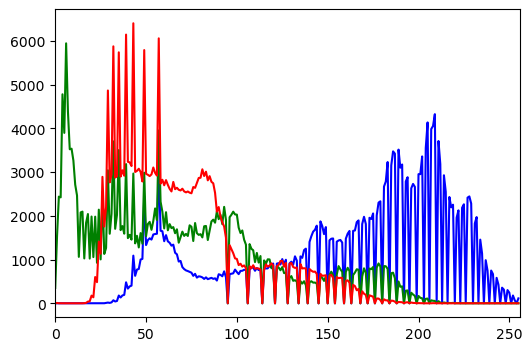

In [19]:
plot_rgb_hist(result_image, histSize, range)
plt.show()

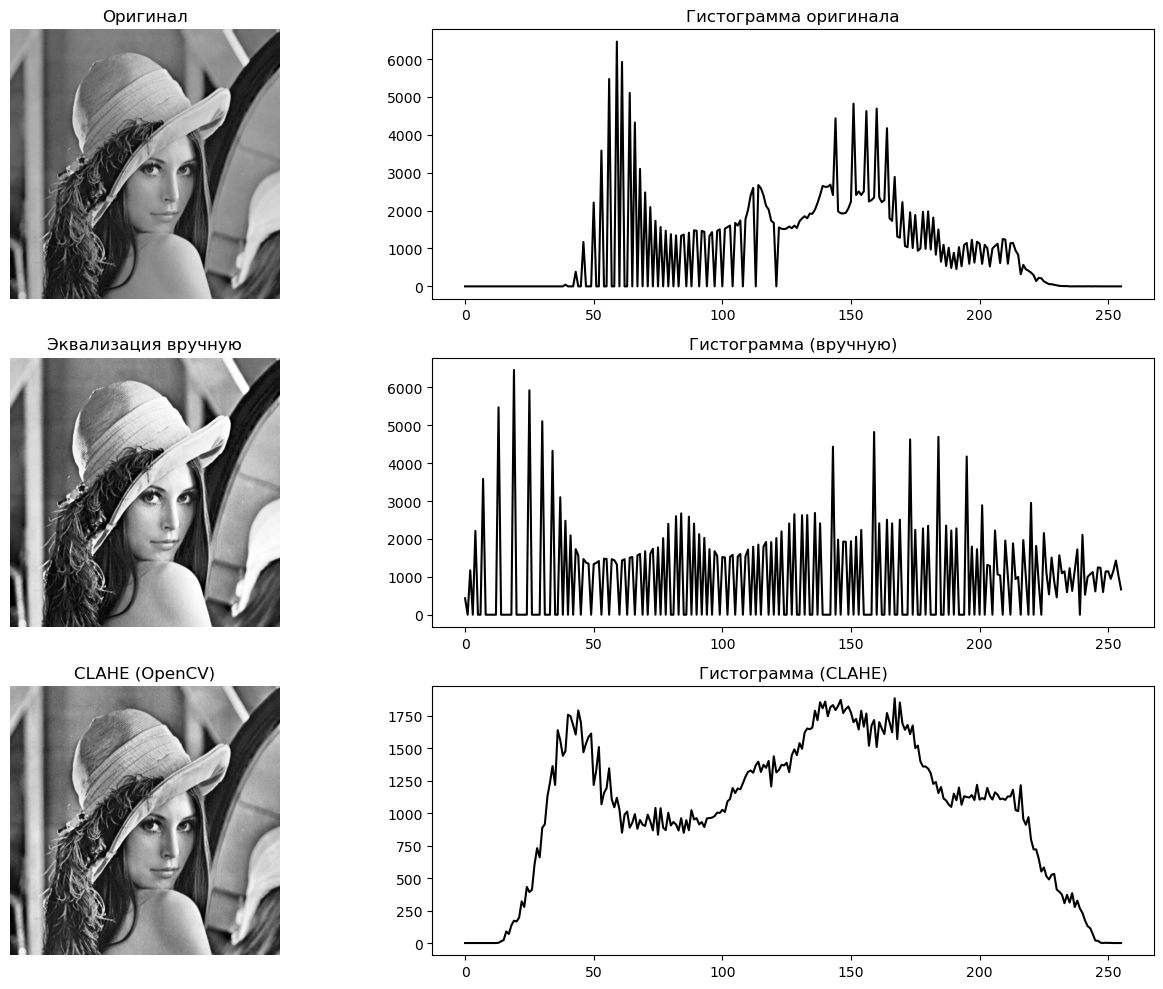

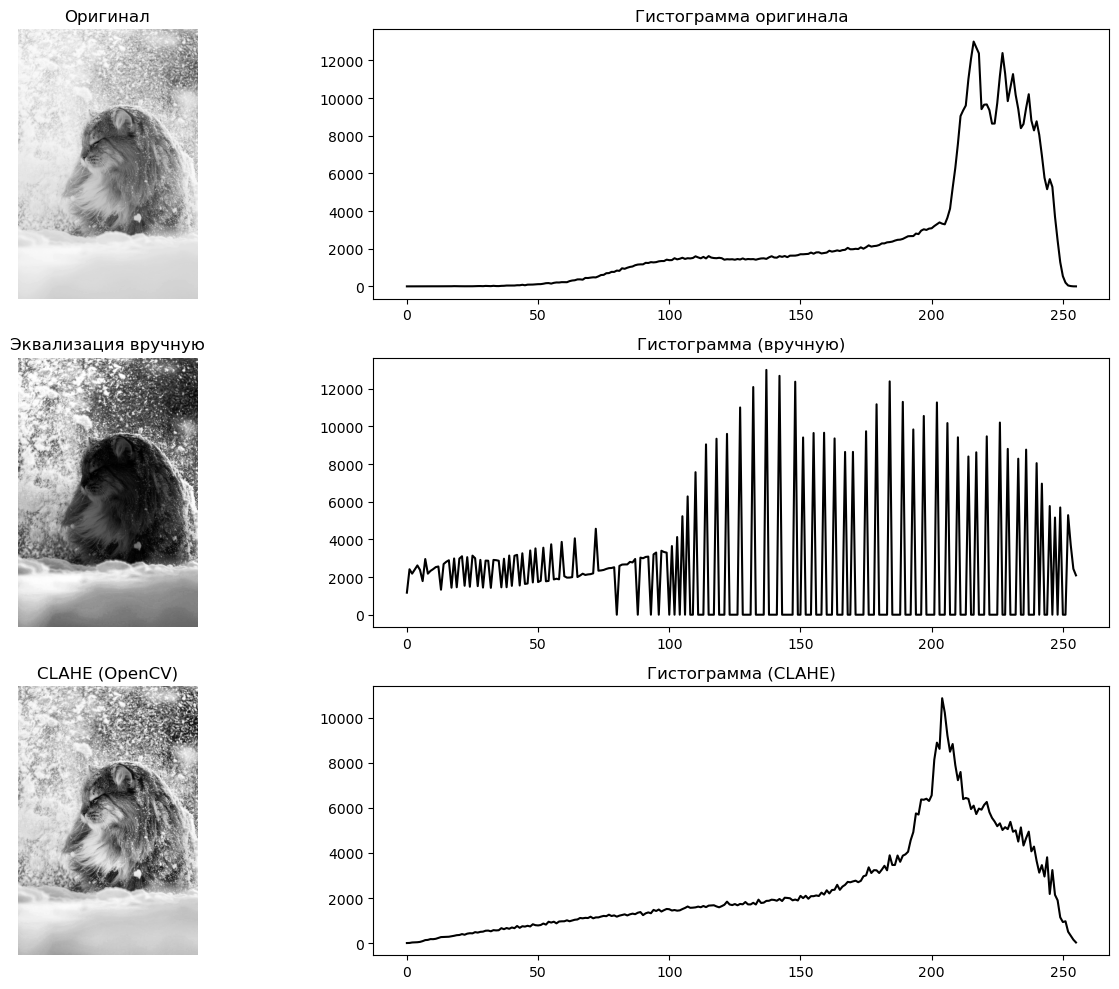

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def manual_equalization(img: np.ndarray) -> np.ndarray:
    hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    cdf = hist.cumsum()
    cdf_normalized = 255 * cdf / cdf[-1]
    lut = np.round(cdf_normalized).astype(np.uint8)
    return lut[img]


def apply_clahe(img: np.ndarray, clip_limit=2.0, grid_size=(8, 8)) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    return clahe.apply(img)


def plot_results(original, manual, clahe):
    hist_original = cv2.calcHist([original], [0], None, [256], [0, 256])
    hist_manual = cv2.calcHist([manual], [0], None, [256], [0, 256])
    hist_clahe = cv2.calcHist([clahe], [0], None, [256], [0, 256])

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.axis('off')
    plt.title('Оригинал')

    plt.subplot(3, 2, 2)
    plt.plot(hist_original, color='black')
    plt.title('Гистограмма оригинала')

    plt.subplot(3, 2, 3)
    plt.imshow(manual, cmap='gray')
    plt.axis('off')
    plt.title('Эквализация вручную')

    plt.subplot(3, 2, 4)
    plt.plot(hist_manual, color='black')
    plt.title('Гистограмма (вручную)')

    plt.subplot(3, 2, 5)
    plt.imshow(clahe, cmap='gray')
    plt.axis('off')
    plt.title('CLAHE (OpenCV)')

    plt.subplot(3, 2, 6)
    plt.plot(hist_clahe, color='black')
    plt.title('Гистограмма (CLAHE)')

    plt.tight_layout()
    plt.show()


def process_image(filename: str):
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    manual = manual_equalization(img)
    clahe = apply_clahe(img)
    plot_results(img, manual, clahe)

process_image("lenna.png")
process_image("winter_cat.png")